In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
startup = pd.read_csv('50_Startups.csv')

In [132]:
startup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [133]:
startup['State'].unique()

array(['New York', 'California', 'Florida'], dtype=object)

In [134]:
startup.head(50)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


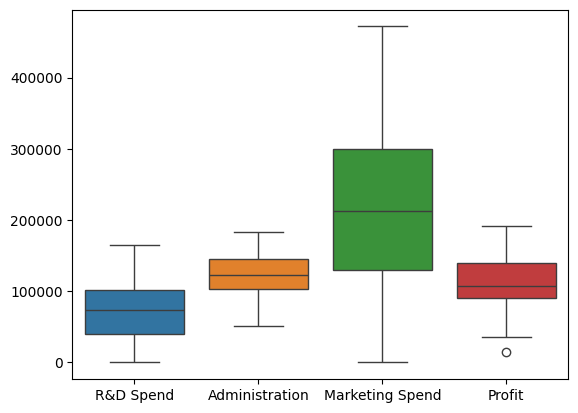

In [135]:
sns.boxplot(startup)
plt.show()

## MODEL

In [136]:
X_before = startup[['R&D Spend', 'Administration', 'Marketing Spend']]
y = startup['Profit']

In [137]:
X = (X_before - X_before.min()) / (X_before.max() - X_before.min())
# X = (X_before - X_before.mean()) / X_before.std()

In [138]:
def split_data(X, y, train_size=0.6, random_state=42):
    np.random.seed(random_state)
    idx = np.random.permutation(len(X))
    split = int(train_size * len(X))

    X_train = X.iloc[idx[:split]]
    y_train = y.iloc[idx[:split]]
    X_test = X.iloc[idx[split:]]
    y_test = y.iloc[idx[split:]]

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(X, y)

In [139]:
def bias(X):
    return np.c_[np.ones(X.shape[0]), X]

def linear_regression(X_train, y_train, X_test):
    X_train_b, X_test_b = bias(X_train), bias(X_test)
    beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
    y_pred = X_test_b @ beta

    return beta, y_pred

beta, y_pred = linear_regression(X_train, y_train, X_test)

In [140]:
RSS = np.sum((y_test - y_pred)**2)
TSS = np.sum((y_test - y_test.mean())**2)

R2 = 1 - RSS / TSS
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred)**2)
rmse = np.sqrt(mse)

print(f'R2      : {R2:.2f}')
print(f'MAE     : {mae:.4f}')
print(f'MSE     : {mse:.4f}')
print(f'RMSE    : {rmse:.4f}')

R2      : 0.92
MAE     : 8812.1977
MSE     : 138267174.7484
RMSE    : 11758.7063
